# AP 155 Lab Exercise
---
## Exercise 4: Derivatives (Non-central and central difference approximations)

_Instructions_: 
- **Report figure:** Log-log plot of MAE vs $h$ using first-order forward-difference, backward-difference and central-difference formulas
- **Report discussion:** Explain the resulting shape of your figure. Explain which regime is dominated by mathematical truncation error and which is dominated by floating-point machine precision (subtractive cancellation). What are the optimal step sizes $h^*$ for each method? Looking outward, when is each method of differentiation suitable/appropriate?
      
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle
- _Student No._: 2024-11845
- _Section_: THR-TX-_

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

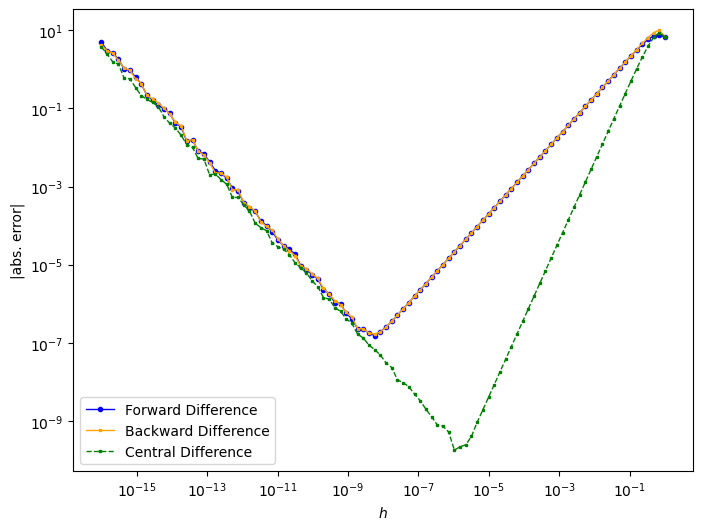

In [152]:
fig

**Figure: Mean Absolute Error (MAE) vs. Step Size (*h*) for Numerical Derivative Approximations** 

The relationship between the `Mean Absolute Error (MAE)` and the `step size (*h*)` for the forward, backward, and central difference approximations of the first derivative is shown in this log-log plot.

### Report discussion

(1) For each of the three numerical differentiation techniques, the figure has a `U-shaped pattern`. The MAE initially drops as the step size (*h*) decreases from large values because the derivative approximation gets more accurate. Every technique achieves a minimum error at an ideal (*h*). The MAE rises once more when *h* gets very small because of subtractive cancellation and floating-point rounding errors. Due to its higher-order accuracy, the central difference has a significantly lower minimum error than the forward and backward differences. 
\
\
(2)  Mathematical truncation error dominates the error for large *h*. When the spacing is too great, the infinite difference formulas lose some of their accuracy in approximating the derivative. Truncation error decreases as *h* decreases. `Subtractive cancellation` and `floating-point precision` are dominant for very small *h*. Significant digits are lost during subtraction when the terms $f(x+h)$ and $f(x-h)$ become almost equal. This explains why the MAE rises once more as *h* gets closer to $10^{-16}$.
\
\
(3) The `optimal step size` ($h^*$) for each method is found at the minimum point of its respective curve on the log-log plot, where the truncation error and machine precision error are roughly balanced. From the plot:

*   For **Forward Difference**, $h^*$ is approximately $10^{-8}$.
*   For **Backward Difference**, $h^*$ is approximately $10^{-8}$.
*   For **Central Difference**, $h^*$ is approximately $10^{-6}$.
\
\
Looking outward, each method of differentiation is suitable for different scenarios. The `central difference` is preferred when data is available on both sides because it is more accurate, with $O(h^2)$ accuracy, making it **generally better for numerical differentiation**. In contrast, forward and bacward differences are best suited for situations where data is available on only one side of a point, such as at boundaries. They are simpler but less accurate with $O(h)$ accuracy.

### Other comments

- Indentation is really tricky. Super na-fu-frustrate ako kapag hindi gumagana yung code. Yun po pala mali ang indentation T^T. 
- I love green. Yes, I love green.
- Nung naaral ko na po yung ibang fundamentals, mas nag-me-make sense na po sa akin yung pag-build ng code for the exercises.
- I also approached this exercise as a way to practice adding comments and docstrings to my code. At first, hindi po ako naglalagay kasi I thought it made the code bulky. Now, I know how important they are. 

#### Disclosure of AI Use:

I acknowledge the use of Gemini (accessed September 2026) to generate a first draft of the plotting algorithms for parts (d) and (e) of Section 2 with regards on how to use the loglog function. All AI-assisted suggestions were reviewed and revised with the use of the references to ensure accuracy and clarity of meaning.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem:

Consider the function:
$$ f(x) = 10\cos(2\pi x - 5)e^{-x} \tag{1}.$$

(a) Start by analytically evaluating the first derivative and creating a function that plots the analytical first derivative with $257$ points from $0$ to $2\pi$.

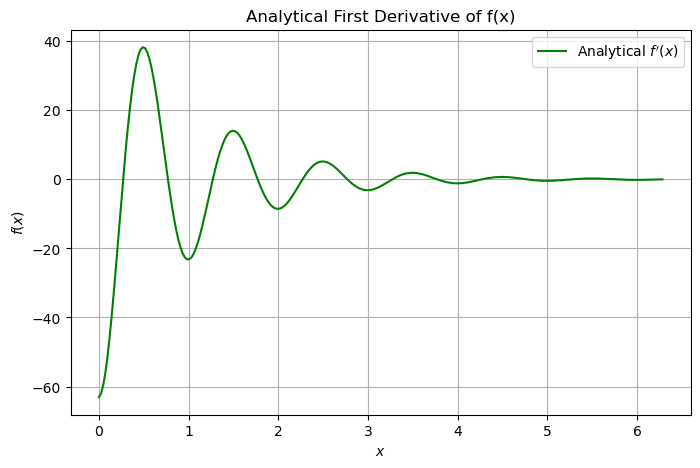

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Evaluating f(x) = 10cos(2*pi*x - 5)e^(-x)
def f(x):
    """The original function f(x)."""
    return 10 * np.cos(2 * np.pi * x - 5) * np.exp(-x)

# Evaluate using product rule and chain rule:
# f'(x) = [-20*pi*sin(2*pi*x - 5)e^(-x) - 10cos(2*pi*x - 5)e^(-x)]
def f_prime_analytical(x):
    """The analytical first derivative of f(x)."""
    term_1 = -20 * np.pi * np.sin(2 * np.pi * x - 5) 
    term_2 = -10 * np.cos(2 * np.pi * x - 5)
    return (term_1 + term_2) * np.exp(-x)

# Plot analytical first derivative with 257 points
def plot_analytical_derivative(num_pts=257):
    """This plots the analytical first derivative from 0 to 2*pi."""
    x = np.linspace(0, 2 * np.pi, num_pts)

    # Show the figure plot of the analytical first derivative of f(x)
    # Make sure that indentation is correct
    plt.figure(figsize=(8,5))
    plt.plot(x, f_prime_analytical(x), label="Analytical $f'(x)$", color='green') # greeen <3
    plt.title("Analytical First Derivative of f(x)")
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_analytical_derivative()

(b) Create three functions that calculates the first derivative approximation using the forward, backward, and central difference formulas. *(Bonus, not required): Make the function flexible to non-evenly spaced data*

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Use current point and a point ahead in the future (x + h) to get forward difference
def forward_difference(f,x,h):
    """ 
    Calculates the first derivative using the forward difference formula:
    f'(x) = (f(x + h) - f(x)) / h
    """
    return (f(x + h) - f(x)) / h

# Use current point and a point behind in the past (x - h) to get backward difference
def backward_difference(f,x,h):
    """
    Calculates the first derivative using the backward difference formula:
    f'(x) = (f(x) - f(x - h)) / h
    """
    return (f(x) - f(x - h)) / h

# Uses one point ahead (x + h) and one point behind (x - h)
def central_difference(f,x,h):
    """
    Calculates the first derivative using the central difference formula:
    f'(x) = (f(x + h) - f(x - h)) / (2 * h)
    """
    return (f(x + h) - f(x - h)) / (2 * h)

(c) To give yourself a visualization, plot (in a single figure), the three derivative approximations and the analytically derived function evaluated from $0$ to $2\pi$ with $257$ points. Test what happens when you vary the number of points.

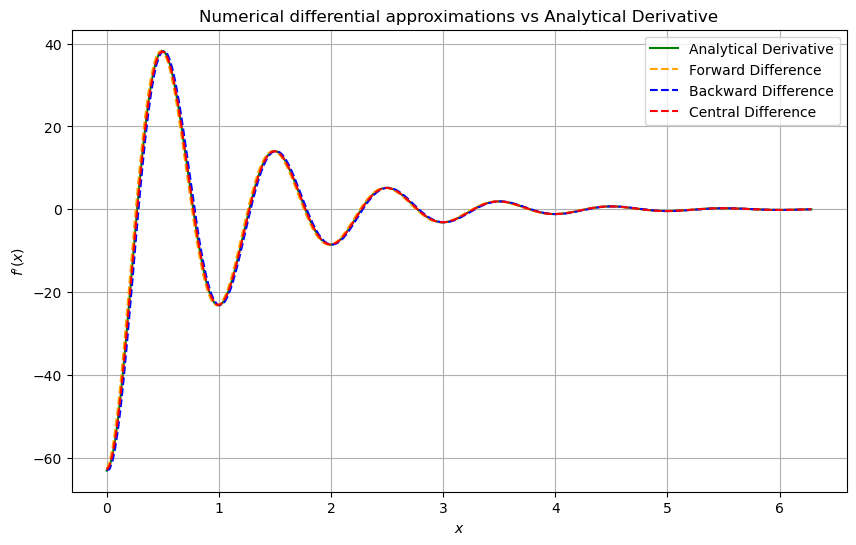

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# First define parameters
num_pts = 257 # No. of points
x = np.linspace(0, 2 * np.pi, num_pts) # X-values from 0 to 2*pi
h = x[1] - x[0] # Calculate difference between the points

# Derivative approximations
forward = forward_difference(f,x,h)
backward = backward_difference(f,x,h)
central = central_difference(f,x,h)

# Then calculate the analytical derivative
analytical_derivative = f_prime_analytical(x)

# Plot all four derivatives in a single figure
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(x, analytical_derivative, label="Analytical Derivative", c='green') # greeeeeen <33
ax.plot(x, forward, '--', label="Forward Difference", c='orange')
ax.plot(x, backward, '--', label="Backward Difference", c='blue')
ax.plot(x, central, '--', label="Central Difference", c='red')

# Other formatting
plt.title("Numerical differential approximations vs Analytical Derivative")
plt.xlabel("$x$")
plt.ylabel("$f'(x)$")
plt.grid(True)
plt.legend()
plt.show()

### When you vary the number of points:

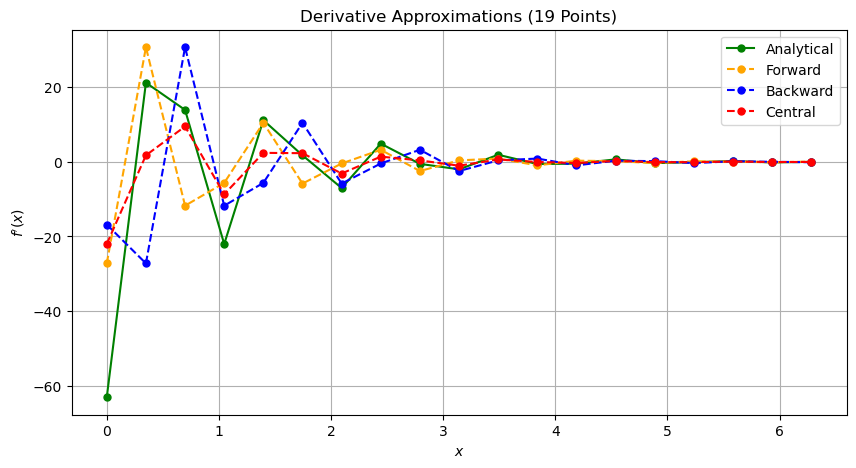

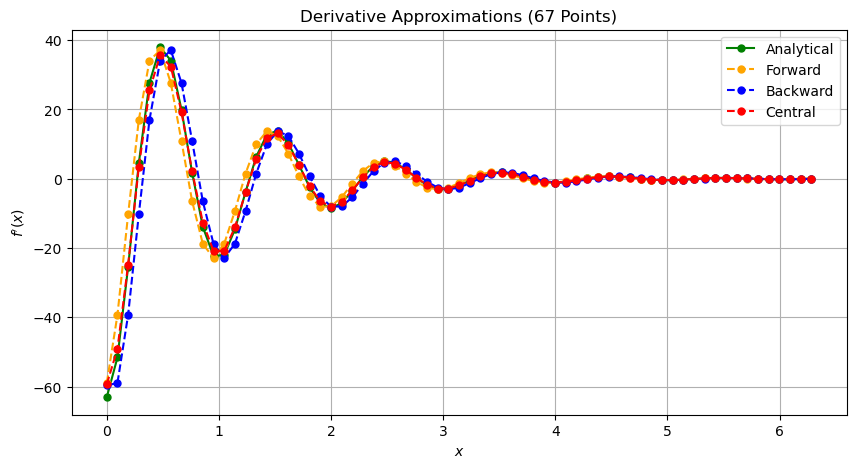

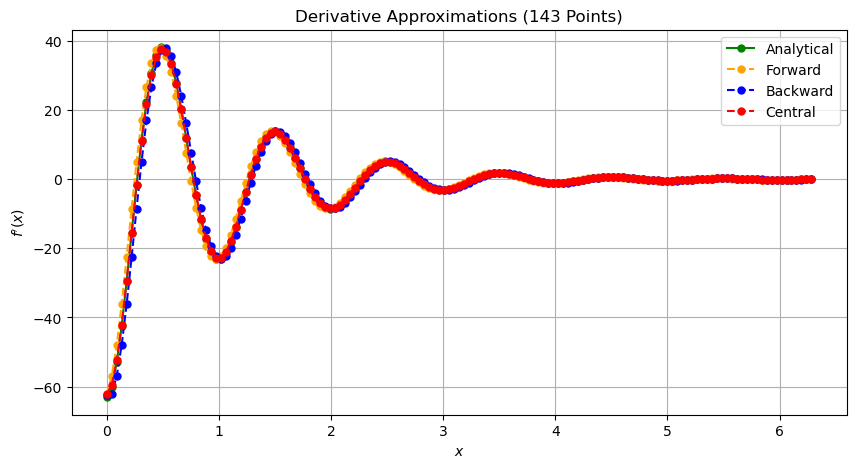

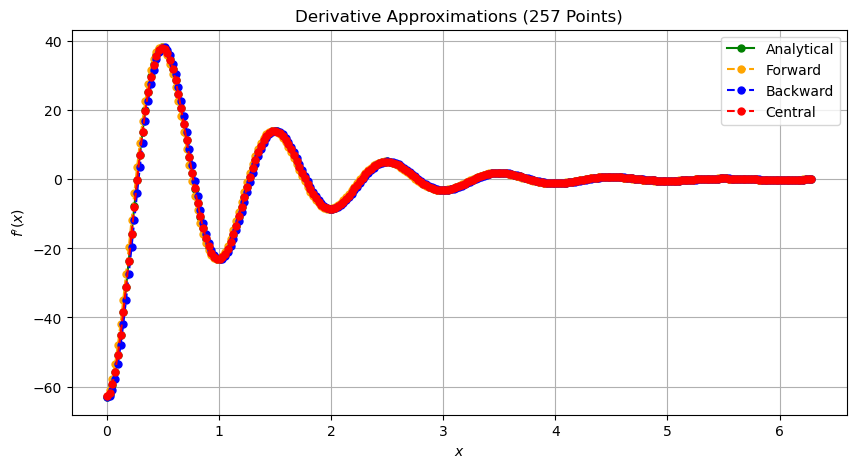

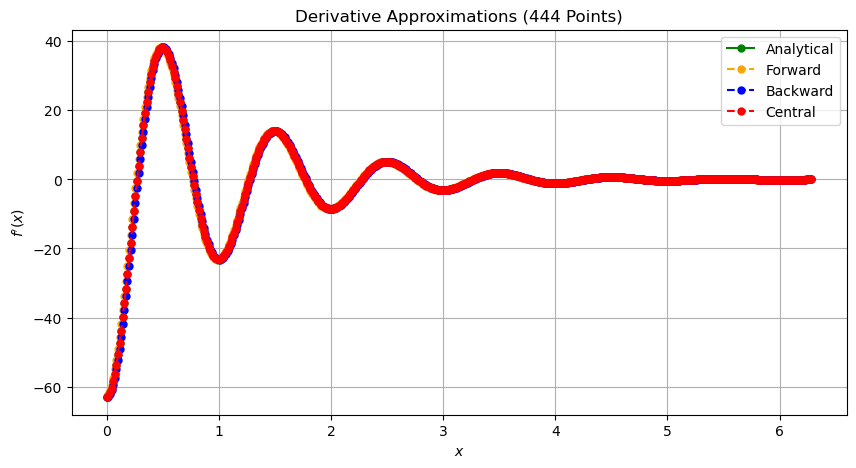

In [153]:
# Plots in varying number of points
# Always be wary of the indentation
for num_pts in [19, 67, 143, 257, 444]:
    x = np.linspace(0, 2 * np.pi, num_pts)
    h = x[1] - x[0]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x, f_prime_analytical(x), label="Analytical", marker='o', ms=5, color='green') # greeeeeeeeen <333
    ax.plot(x, forward_difference(f, x, h), "o--", label="Forward", ms=5, color='orange')
    ax.plot(x, backward_difference(f, x, h), "o--", label="Backward", ms=5, color='blue')
    ax.plot(x, central_difference(f, x, h), "o--", label="Central", ms=5, color='red')

    plt.title(f"Derivative Approximations ({num_pts} Points)")
    plt.xlabel("$x$")
    plt.ylabel("$f'(x)$")
    plt.grid(True)
    plt.legend()
    plt.show()

(d) Create a function (or lambda function) that calculates the mean absolute error of two sets of data (the approximations vs analytical values) for a given $h$. The mean absolute error is given by
$$ \text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i -\tilde{y}_i|$$
where $n$ is the total number of points, $y_i$ is the approximated value, and $\tilde{y}_i$ is the analytical value.

In [133]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_mae(approximated_values, analytical_values):
    """
    Calculates the Mean Absolute Error (MAE) between approximated and analytical values.
    Args:
        approximated_values (numpy.ndarray): An array of approximated derivative values.
        analytical_values (numpy.ndarray): An array of analytical derivative values.
    Returns:
        float: The Mean Absolute Error.
    """
    # Make sure that both arrays have the same length
    if len(approximated_values) != len(analytical_values):
        raise ValueError("Arrays must have the same length.")

    n = len(approximated_values)
    if n == 0:
        return 0.0 # MAE is 0 for no points

    mae = np.sum(np.abs(approximated_values - analytical_values)) / n
    return mae

In [132]:
# Or as a lambda function:

calculate_mae_lambda = lambda approximated_values, analytical_values: np.sum(np.abs(approximated_values - analytical_values)) / len(approximated_values)

(e) **[REPORT FIGURE]** Generate a plot of the MAE for the three approximations vs the spacing between points $h$. You can use $h\in[10^{-16}, 10^0]$. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation. It should look something like Fig 3.2 of Gezerlis.

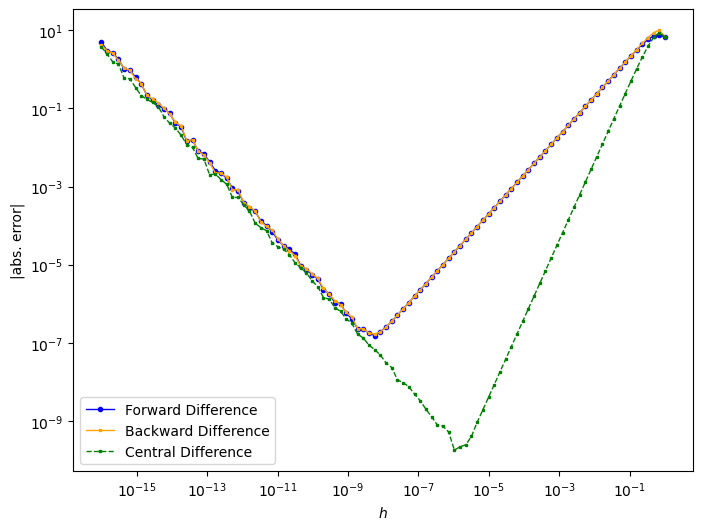

In [151]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_mae(approximated_values, analytical_values):
    """
    Return the mean absolute error (MAE).
    """
    return np.mean(np.abs(approximated_values - analytical_values))

# Generate h values from 10^-16 to 10^0
h_values = np.logspace(-16, 0, 100)

# Store MAE values
mae_forward = []
mae_backward = []
mae_central = []

# Evaluation point
x = np.linspace(0, 2 * np.pi, 257)

# Analytical derivative
analytical = f_prime_analytical(x)

# Compute MAE for each h
for h in h_values:
    forward = forward_difference(f, x, h)
    backward = backward_difference(f, x, h)
    central = central_difference(f, x, h)

    mae_forward.append(calculate_mae(forward, analytical))
    mae_backward.append(calculate_mae(backward, analytical))
    mae_central.append(calculate_mae(central, analytical))

# Plot MAE versus Step Size for Numerical Differentiation
fig, ax= plt.subplots(figsize=(8, 6))

ax.loglog(h_values, mae_forward, label="Forward Difference", lw=1, marker='o', ms=3, c='blue')
ax.loglog(h_values, mae_backward, label="Backward Difference", lw=1, marker='s', ms=2, c='orange')
ax.loglog(h_values, mae_central, '--', label="Central Difference", lw=1, marker='s', ms=2, c='green') # greeeeeeeeeeeen <3333

plt.xlabel("$h$")
plt.ylabel("|abs. error|")
plt.grid(False)
plt.legend()

plt.show()

#### Problem 1 code summary

The script uses forward, backward, and central difference formulas to approximate a given function's first derivative. The `Mean Absolute Error (MAE)` for each approximation technique is then computed over a range of step sizes (*h*). In order to analyze the truncation and machine precision errors, the core algorithm iterates through different *h* values, applies each difference formula, and plots the MAE on a log-log scale. 

---

#### EXTRA:
Try to create your own function $f$ and use the approximations to calculate its first derivative.

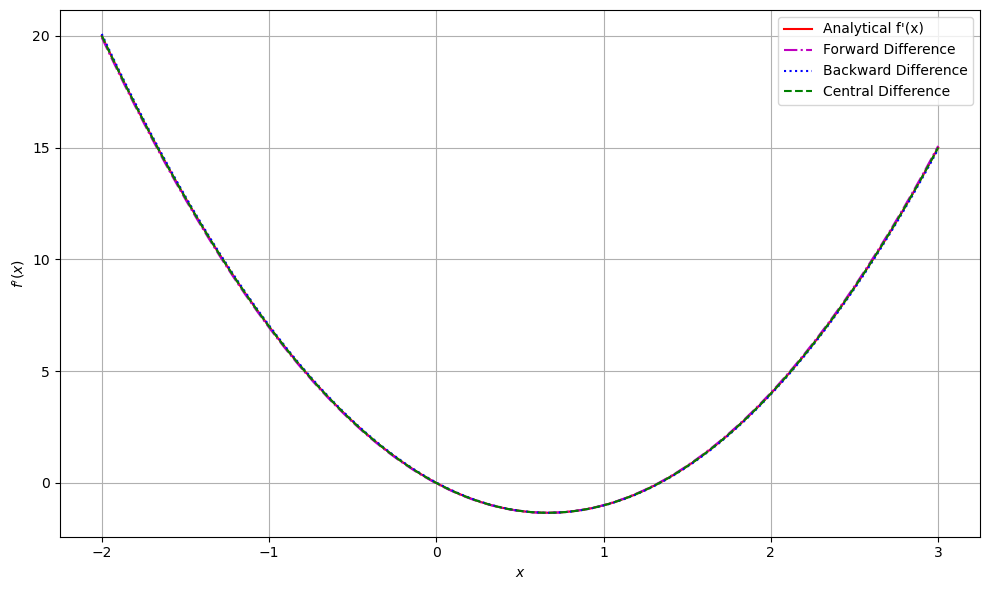

In [150]:
import numpy as np
import matplotlib.pyplot as plt

# I want to define a random function
def f_new(x):
    """
    Let the new function be: x^3 - 2x^2 + 5.
    """
    return x**3 - 2*x**2 + 5

# Analytical first derivative
def f_prime_new_analytical(x):
    """
    The analytical first derivative of f_new(x): 3x^2 - 4x.
    """
    return 3*x**2 - 4*x

# Then, we define the parameters for plotting and approximation
num_pts_new = 100
x_new = np.linspace(-2, 3, num_pts_new) 
h_new = 0.01 

# Calculate the analytical derivative
analytic_deriv_new = f_prime_new_analytical(x_new)

# Calculate the approximation using the previously defined functions
forward_approx_new = np.array([forward_difference(f_new, val, h_new) for val in x_new])
backward_approx_new = np.array([backward_difference(f_new, val, h_new) for val in x_new])
central_approx_new = np.array([central_difference(f_new, val, h_new) for val in x_new])

# Plot the diagram
figure, ax = plt.subplots(figsize=(10,6))

ax.plot(x_new, analytic_deriv_new, 'r-', label="Analytical f'(x)")
ax.plot(x_new, forward_approx_new, 'm-.', label="Forward Difference")
ax.plot(x_new, backward_approx_new, 'b:', label="Backward Difference")
ax.plot(x_new, central_approx_new, 'g--', label="Central Difference") # greeeeeeeeeeeeeeen <33333

plt.xlabel("$x$")
plt.ylabel("$f'(x)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [2]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]


In [1]:
# finitediff.py from Gezerlis

from math import exp, sin, cos

def f(x):
    return exp(sin(2*x))

def fprime(x):
    return 2*exp(sin(2*x))*cos(2*x)

def calcfd(f,x,h):
    fd = (f(x+h) - f(x))/h
    return fd

def calccd(f,x,h):
    cd = (f(x+h/2) - f(x-h/2))/h
    return cd

if __name__ == '__main__':
    x = 0.5
    an = fprime(x)
    hs = [10**(-i) for i in range(1,12)]
    fds = [abs(calcfd(f,x,h) - an) for h in hs]
    cds = [abs(calccd(f,x,h) - an) for h in hs]
    rowf = "{0:1.0e}{1:1.16f} {2:1.16f}"
    print("h abs. error in fd abs. error in cd")
    for h,fd,cd in zip(hs,fds,cds):
        print(rowf.format(h,fd,cd))

h abs. error in fd abs. error in cd
1e-010.3077044583376249 0.0134656094697734
1e-020.0260359156900742 0.0001350472493096
1e-030.0025550421497806 0.0000013505116288
1e-040.0002550180941236 0.0000000135077878
1e-050.0000254969542519 0.0000000001495843
1e-060.0000025492660578 0.0000000002500959
1e-070.0000002564334673 0.0000000011382744
1e-080.0000000255070782 0.0000000189018428
1e-090.0000003741732106 0.0000000699159992
1e-100.0000021505300500 0.0000021505300500
1e-110.0000332367747395 0.0000111721462455
